<b>Detecting AI-Generated Text</b>

<i>In this project, I am to build a model which can recognise which text was written by human or AI.</i>

1.<u>Data preprocessing<u>

<i>Importing modules</i>

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<i>Importing dataset</i>

In [155]:
dataset=pd.read_csv(r"C:\Users\Abhijyot Singh Roda\Desktop\Coding Stuff\Python\Projects\Not so random projects\ML Projects\Datasets\ai_human_text.csv")

<i>Information about the dataset</i>

In [156]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6069 entries, 0 to 6068
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6069 non-null   int64 
 1   Text        6069 non-null   object
 2   Author      6069 non-null   object
dtypes: int64(1), object(2)
memory usage: 142.4+ KB


<i>First 5 rows</i>

In [157]:
dataset.head()

,Unnamed: 0,Text,Author
0,0,This study investigates the chemical compositi...,AI
1,1,This study explores the cultural history of oi...,AI
2,2,Isolation of human peripheral blood mononucle...,Human
3,3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,4,"Within volleyball, performance analysis is em...",Human


<i>Last 5 rows</i>

In [158]:
dataset.tail()

,Unnamed: 0,Text,Author
6064,6064,Computational models serve as useful compleme...,Human
6065,6065,During transport and storage of drinking wate...,Human
6066,6066,The parameter values of neural networks will ...,Human
6067,6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,Human
6068,6068,Generative AI for video is computationally exp...,AI


<i>Removing unnecessary columns</i>

In [159]:
dataset=dataset.drop(["Unnamed: 0"],axis="columns")

- Updated dataset

In [160]:
dataset.head()

,Text,Author
0,This study investigates the chemical compositi...,AI
1,This study explores the cultural history of oi...,AI
2,Isolation of human peripheral blood mononucle...,Human
3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,"Within volleyball, performance analysis is em...",Human


<i>Cleaning text</i>

In [161]:
import re
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

corpus=[]
for i in range(6069):
    review=re.sub("[^a-zA-Z]"," ",dataset["Text"][i])
    review=review.lower()
    review=review.split()
    ps=PorterStemmer()
    review=[ps.stem(word) for word in review if not word in set(stopwords.words("english"))]
    review=" ".join(review)
    corpus.append(review)

[nltk_data] Downloading package stopwords to C:\Users\Abhijyot Singh
[nltk_data]     Roda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<i>Creating Bag of Words</i>

In [162]:
from sklearn.feature_extraction.text import CountVectorizer

cv=CountVectorizer(max_features=3000,min_df=5,max_df=0.9)
X=cv.fit_transform(corpus).toarray()
y=dataset.iloc[:,-1].values

<i>Splitting the dataset into training and test set</i>

In [163]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

2.<u>Building multiple models</u>

<b>a. Logistic Regression</b>

<i>Model building</i>

In [164]:
from sklearn.linear_model import LogisticRegression

classifier1=LogisticRegression(class_weight="balanced")
classifier1.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


<i>Predicting the values for training and test set</i>

In [165]:
y_pred_train_1=classifier1.predict(X_train)
y_pred_test_1=classifier1.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_1.reshape(len(y_pred_train_1),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_1.reshape(len(y_pred_test_1),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[['Human' 'Human']
 ['Human' 'Human']
 ['Human' 'Human']
 ...
 ['Human' 'Human']
 ['Human' 'Human']
 ['AI' 'AI']]

For the test set:
[Actual_Observations Predicted_Observations]
[['Human' 'Human']
 ['Human' 'Human']
 ['AI' 'AI']
 ...
 ['AI' 'AI']
 ['AI' 'AI']
 ['AI' 'AI']]


<i>Accuracy of the model</i>

Accuracy for the training set: 99.979403%
Accuracy for the test set: 99.011532%

Confusion matrix for the training set:


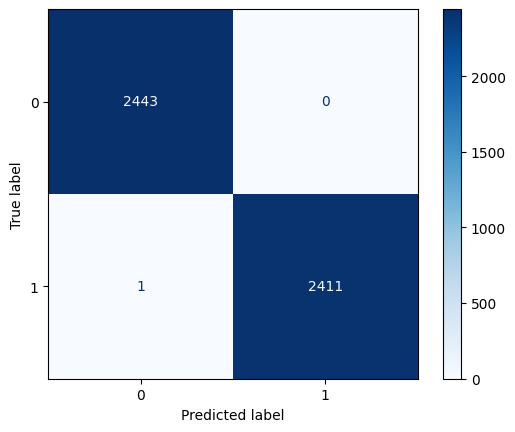

Confusion matrix for the test set:


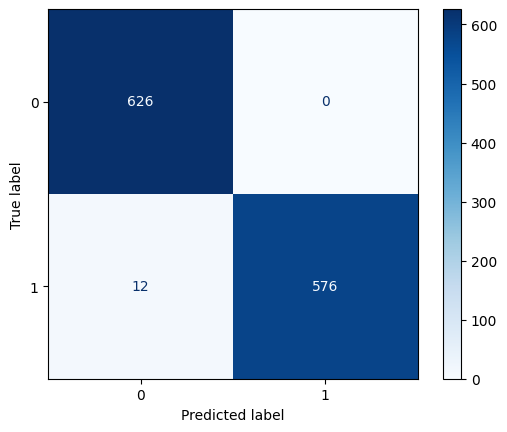

In [166]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_lr_1=confusion_matrix(y_train,y_pred_train_1)
con_mat_lr_2=confusion_matrix(y_test,y_pred_test_1)

disp_lr_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_lr_1)
disp_lr_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_lr_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_1)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_1)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_lr_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_lr_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [167]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_1))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_1))

Classification report for the training set:
              precision    recall  f1-score   support

          AI       1.00      1.00      1.00      2443
       Human       1.00      1.00      1.00      2412

    accuracy                           1.00      4855
   macro avg       1.00      1.00      1.00      4855
weighted avg       1.00      1.00      1.00      4855


Classification report for the test set:
              precision    recall  f1-score   support

          AI       0.98      1.00      0.99       626
       Human       1.00      0.98      0.99       588

    accuracy                           0.99      1214
   macro avg       0.99      0.99      0.99      1214
weighted avg       0.99      0.99      0.99      1214



<b>b. K-Nearest Neighbours Classification</b>

<i>Model building</i>

In [168]:
from sklearn.neighbors import KNeighborsClassifier

classifier2=KNeighborsClassifier(n_neighbors=5,metric="minkowski",p=2)
classifier2.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


<i>Predicting the values for training and test set</i>

In [169]:
y_pred_train_2=classifier2.predict(X_train)
y_pred_test_2=classifier2.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_2.reshape(len(y_pred_train_2),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_2.reshape(len(y_pred_test_2),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[['Human' 'AI']
 ['Human' 'AI']
 ['Human' 'AI']
 ...
 ['Human' 'AI']
 ['Human' 'AI']
 ['AI' 'AI']]

For the test set:
[Actual_Observations Predicted_Observations]
[['Human' 'AI']
 ['Human' 'AI']
 ['AI' 'AI']
 ...
 ['AI' 'AI']
 ['AI' 'AI']
 ['AI' 'AI']]


<i>Accuracy of the model</i>

Accuracy for the training set: 57.363543%
Accuracy for the test set: 56.672158%

Confusion matrix for the training set:


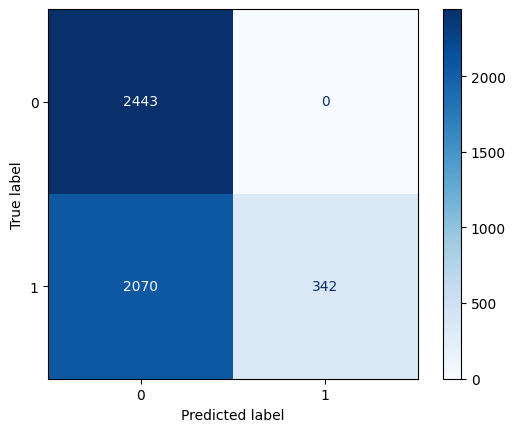

Confusion matrix for the test set:


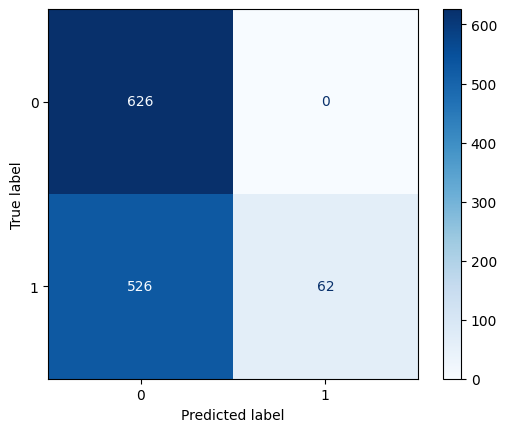

In [170]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_knn_1=confusion_matrix(y_train,y_pred_train_2)
con_mat_knn_2=confusion_matrix(y_test,y_pred_test_2)

disp_knn_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_knn_1)
disp_knn_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_knn_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_2)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_2)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_knn_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_knn_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [171]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_2))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_2))

Classification report for the training set:
              precision    recall  f1-score   support

          AI       0.54      1.00      0.70      2443
       Human       1.00      0.14      0.25      2412

    accuracy                           0.57      4855
   macro avg       0.77      0.57      0.48      4855
weighted avg       0.77      0.57      0.48      4855


Classification report for the test set:
              precision    recall  f1-score   support

          AI       0.54      1.00      0.70       626
       Human       1.00      0.11      0.19       588

    accuracy                           0.57      1214
   macro avg       0.77      0.55      0.45      1214
weighted avg       0.76      0.57      0.46      1214



<b>c. Naive Baye's Classification</b>

<i>Model building</i>

In [172]:
from sklearn.naive_bayes import GaussianNB

classifier3=GaussianNB()
classifier3.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


<i>Predicting the values for training and test set</i>

In [173]:
y_pred_train_3=classifier3.predict(X_train)
y_pred_test_3=classifier3.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_3.reshape(len(y_pred_train_3),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_3.reshape(len(y_pred_test_3),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[['Human' 'Human']
 ['Human' 'Human']
 ['Human' 'Human']
 ...
 ['Human' 'Human']
 ['Human' 'Human']
 ['AI' 'AI']]

For the test set:
[Actual_Observations Predicted_Observations]
[['Human' 'Human']
 ['Human' 'Human']
 ['AI' 'AI']
 ...
 ['AI' 'AI']
 ['AI' 'AI']
 ['AI' 'Human']]


<i>Accuracy of the model</i>

Accuracy for the training set: 99.629248%
Accuracy for the test set: 95.881384%

Confusion matrix for the training set:


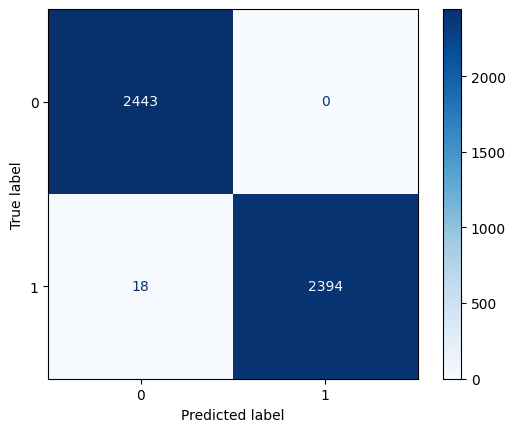

Confusion matrix for the test set:


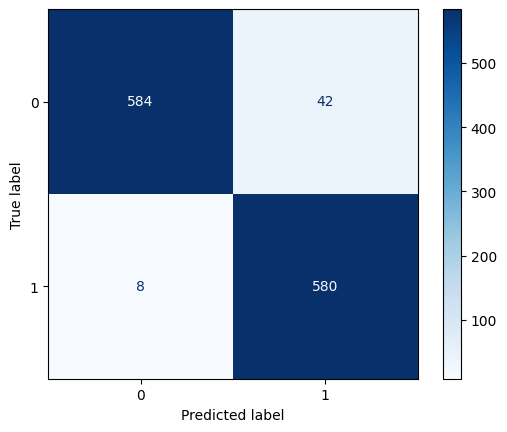

In [174]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_nb_1=confusion_matrix(y_train,y_pred_train_3)
con_mat_nb_2=confusion_matrix(y_test,y_pred_test_3)

disp_nb_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_nb_1)
disp_nb_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_nb_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_3)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_3)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_nb_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_nb_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [175]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_3))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_3))

Classification report for the training set:
              precision    recall  f1-score   support

          AI       0.99      1.00      1.00      2443
       Human       1.00      0.99      1.00      2412

    accuracy                           1.00      4855
   macro avg       1.00      1.00      1.00      4855
weighted avg       1.00      1.00      1.00      4855


Classification report for the test set:
              precision    recall  f1-score   support

          AI       0.99      0.93      0.96       626
       Human       0.93      0.99      0.96       588

    accuracy                           0.96      1214
   macro avg       0.96      0.96      0.96      1214
weighted avg       0.96      0.96      0.96      1214



<b>d. Decision Tree Classifier</b>

<i>Model building</i>

In [176]:
from sklearn.tree import DecisionTreeClassifier

classifier4=DecisionTreeClassifier(criterion="gini",random_state=0,class_weight="balanced")
classifier4.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


<i>Predicting the values for training and test set</i>

In [177]:
y_pred_train_4=classifier4.predict(X_train)
y_pred_test_4=classifier4.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_4.reshape(len(y_pred_train_4),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_4.reshape(len(y_pred_test_4),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[['Human' 'Human']
 ['Human' 'Human']
 ['Human' 'Human']
 ...
 ['Human' 'Human']
 ['Human' 'Human']
 ['AI' 'AI']]

For the test set:
[Actual_Observations Predicted_Observations]
[['Human' 'Human']
 ['Human' 'Human']
 ['AI' 'AI']
 ...
 ['AI' 'AI']
 ['AI' 'AI']
 ['AI' 'AI']]


<i>Accuracy of the model</i>

Accuracy for the training set: 100.000000%
Accuracy for the test set: 94.728171%

Confusion matrix for the training set:


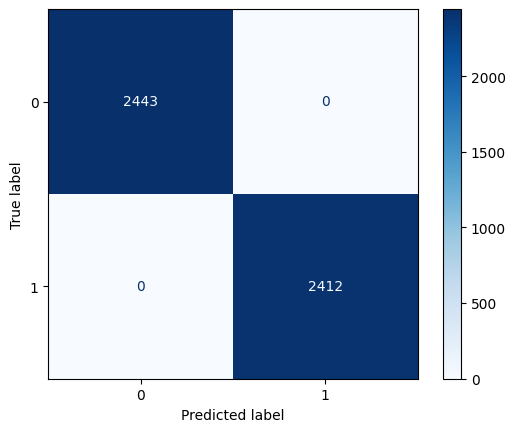

Confusion matrix for the test set:


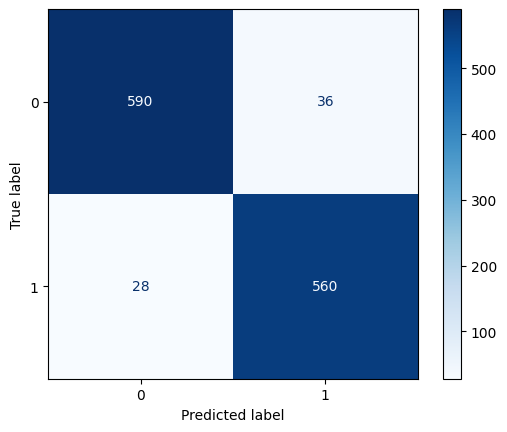

In [178]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_dt_1=confusion_matrix(y_train,y_pred_train_4)
con_mat_dt_2=confusion_matrix(y_test,y_pred_test_4)

disp_dt_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_dt_1)
disp_dt_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_dt_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_4)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_4)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_dt_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_dt_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [179]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_4))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_4))

Classification report for the training set:
              precision    recall  f1-score   support

          AI       1.00      1.00      1.00      2443
       Human       1.00      1.00      1.00      2412

    accuracy                           1.00      4855
   macro avg       1.00      1.00      1.00      4855
weighted avg       1.00      1.00      1.00      4855


Classification report for the test set:
              precision    recall  f1-score   support

          AI       0.95      0.94      0.95       626
       Human       0.94      0.95      0.95       588

    accuracy                           0.95      1214
   macro avg       0.95      0.95      0.95      1214
weighted avg       0.95      0.95      0.95      1214



<b>e. Random Forest Classifier</b>

<i>Model building</i>

In [180]:
from sklearn.ensemble import RandomForestClassifier

classifier5=RandomForestClassifier(n_estimators=500,random_state=0,criterion="gini",max_depth=5,class_weight="balanced")
classifier5.fit(X_train,y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<i>Predicting the values for training and test set</i>

In [181]:
y_pred_train_5=classifier5.predict(X_train)
y_pred_test_5=classifier5.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_5.reshape(len(y_pred_train_5),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_5.reshape(len(y_pred_test_5),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[['Human' 'Human']
 ['Human' 'Human']
 ['Human' 'Human']
 ...
 ['Human' 'Human']
 ['Human' 'Human']
 ['AI' 'AI']]

For the test set:
[Actual_Observations Predicted_Observations]
[['Human' 'Human']
 ['Human' 'Human']
 ['AI' 'AI']
 ...
 ['AI' 'AI']
 ['AI' 'AI']
 ['AI' 'AI']]


<i>Accuracy of the model</i>

Accuracy for the training set: 97.878476%
Accuracy for the test set: 97.528830%

Confusion matrix for the training set:


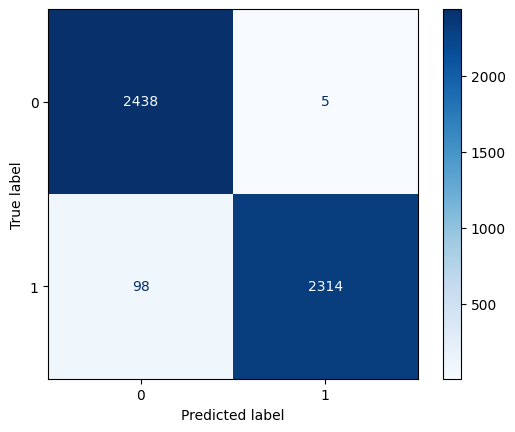

Confusion matrix for the test set:


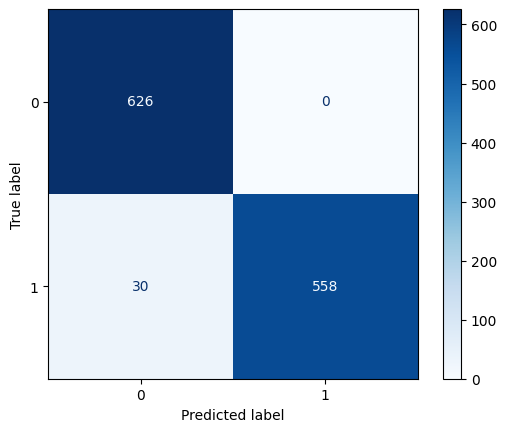

In [182]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_rf_1=confusion_matrix(y_train,y_pred_train_5)
con_mat_rf_2=confusion_matrix(y_test,y_pred_test_5)

disp_rf_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_rf_1)
disp_rf_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_rf_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_5)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_5)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_rf_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_rf_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [183]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_5))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_5))

Classification report for the training set:
              precision    recall  f1-score   support

          AI       0.96      1.00      0.98      2443
       Human       1.00      0.96      0.98      2412

    accuracy                           0.98      4855
   macro avg       0.98      0.98      0.98      4855
weighted avg       0.98      0.98      0.98      4855


Classification report for the test set:
              precision    recall  f1-score   support

          AI       0.95      1.00      0.98       626
       Human       1.00      0.95      0.97       588

    accuracy                           0.98      1214
   macro avg       0.98      0.97      0.98      1214
weighted avg       0.98      0.98      0.98      1214



3.<u>Results</u>

| Model | Train Acc | Test Acc | AI-class Precision | AI-class Recall | AI-class F1 |
|---|---|---|---|---|---|
| Logistic Regression | 99.98% | 99.01% | 0.98 | 1.00 | 0.99 |
| KNN | 57.36% | 56.67% | 0.54 | 1.00 | 0.70 |
| Naive Bayes | 99.63% | 95.88% | 0.99 | 0.93 | 0.96 |
| Decision Tree | 100.00% | 94.73% | 0.95 | 0.94 | 0.95 |
| Random Forest | 97.88% | 97.53% | 0.95 | 1.00 | 0.98 |

**Takeaway:** The classes are fairly balanced (2,443 AI vs 2,412 Human in training; 626 AI vs 588 Human
in test), so overall accuracy is a reasonably informative metric here, though AI-class precision/recall
still fill in the picture. **Logistic Regression** is the clear top performer, with the best test accuracy
(99.01%) and AI-class F1 (0.99), and almost no gap between train and test performance — a sign it
generalizes well rather than overfitting. **Random Forest** is a close second (AI-class F1 0.98). **Naive
Bayes** and **Decision Tree** trail behind, with Decision Tree showing clear overfitting (100% train vs.
94.73% test accuracy). **KNN** performs poorly (56.67% test accuracy), likely because high-dimensional
bag-of-words vectors don't suit a distance-based classifier well. **Logistic Regression** is selected as
the final model for its top performance, strong generalization, simplicity, and interpretability.

4.<u>Model deployment</u>

In [184]:
import pickle as pk

with open(r"LogisticRegression.pk","wb") as file:
    pk.dump(classifier1,file)
    
with open(r"CountVectorizer.pk","wb") as file:
    pk.dump(cv,file)